<h1 style = "
    color : white;
    background : blue;
    border : 2px solid ;
    padding : 30px 10px 30px 10px;
    text-align : center;
    border-radius : 30px 10px
    ">Les Series Temporelles (TimeSeriesSplit)
<h1>

In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
donnes = pd.read_csv("demande_sang_togo.csv")
donnes.head()

,date,temperature_c,precipitations_mm,cas_paludisme,nb_accidents,nb_accouchements,demande_sang
0,2021-01-01,24.8,3.4,33,0,19,75.6
1,2021-01-02,24.4,1.3,30,3,3,58.8
2,2021-01-03,25.0,2.7,34,3,10,63.4
3,2021-01-04,25.8,0.0,30,4,11,69.4
4,2021-01-05,24.4,3.0,30,3,12,68.1


In [3]:
donnes.shape

(1826, 7)

In [4]:
donnes.columns

Index(['date', 'temperature_c', 'precipitations_mm', 'cas_paludisme',
       'nb_accidents', 'nb_accouchements', 'demande_sang'],
      dtype='str')

In [5]:
donnes.isnull().sum()

date                 0
temperature_c        0
precipitations_mm    0
cas_paludisme        0
nb_accidents         0
nb_accouchements     0
demande_sang         0
dtype: int64

In [6]:
donnes.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               1826 non-null   str    
 1   temperature_c      1826 non-null   float64
 2   precipitations_mm  1826 non-null   float64
 3   cas_paludisme      1826 non-null   int64  
 4   nb_accidents       1826 non-null   int64  
 5   nb_accouchements   1826 non-null   int64  
 6   demande_sang       1826 non-null   float64
dtypes: float64(3), int64(3), str(1)
memory usage: 117.8 KB


In [53]:
donnes["date"] = pd.to_datetime(donnes["date"])

In [64]:
donnes.info() #Correction du type de donnes de la variable date

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               1826 non-null   datetime64[us]
 1   temperature_c      1826 non-null   float64       
 2   precipitations_mm  1826 non-null   float64       
 3   cas_paludisme      1826 non-null   int64         
 4   nb_accidents       1826 non-null   int64         
 5   nb_accouchements   1826 non-null   int64         
 6   demande_sang       1826 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(3)
memory usage: 100.0 KB


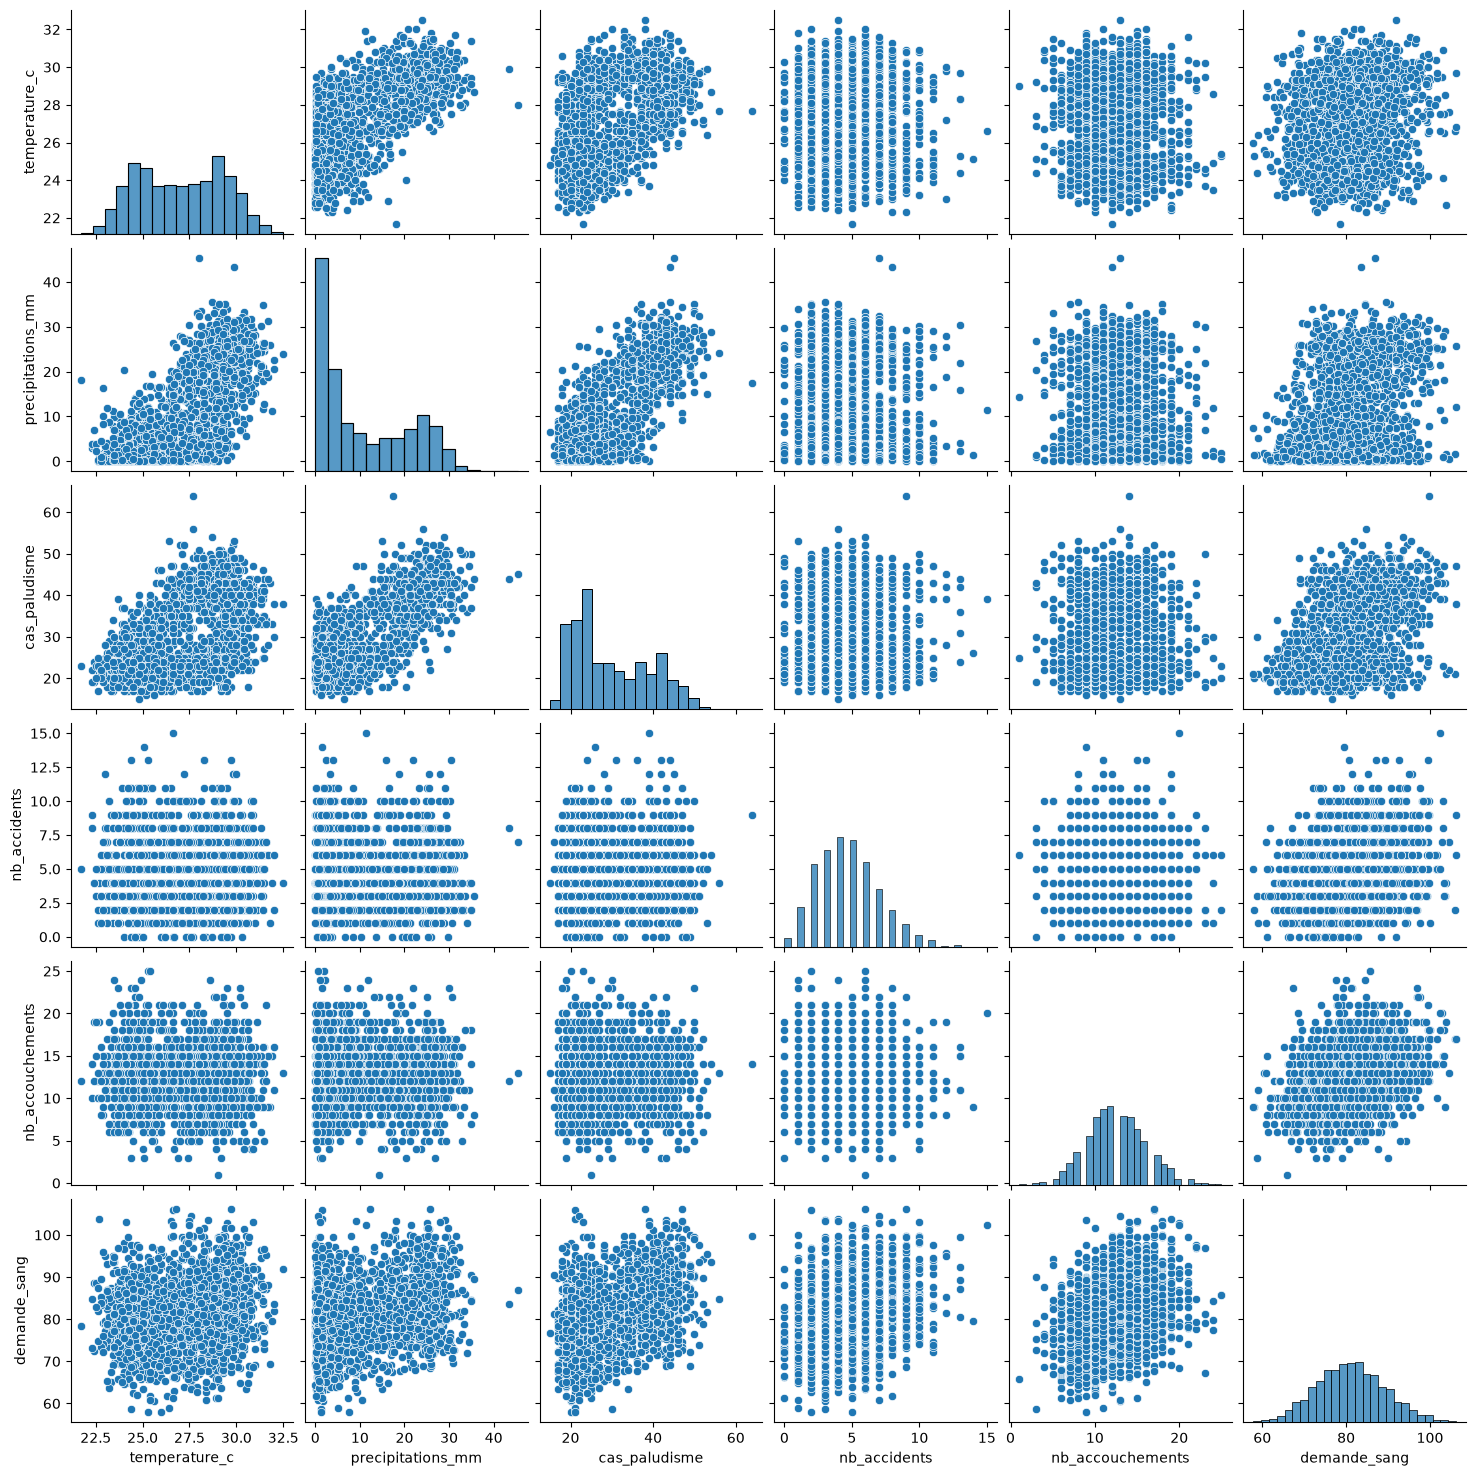

In [7]:
sns.pairplot(donnes)

In [44]:
donnes.columns

Index(['date', 'temperature_c', 'precipitations_mm', 'cas_paludisme',
       'nb_accidents', 'nb_accouchements', 'demande_sang'],
      dtype='str')

In [46]:
colonnes = donnes.columns.tolist()
colonnes = colonnes[1:]
colonnes 

['temperature_c',
 'precipitations_mm',
 'cas_paludisme',
 'nb_accidents',
 'nb_accouchements',
 'demande_sang']

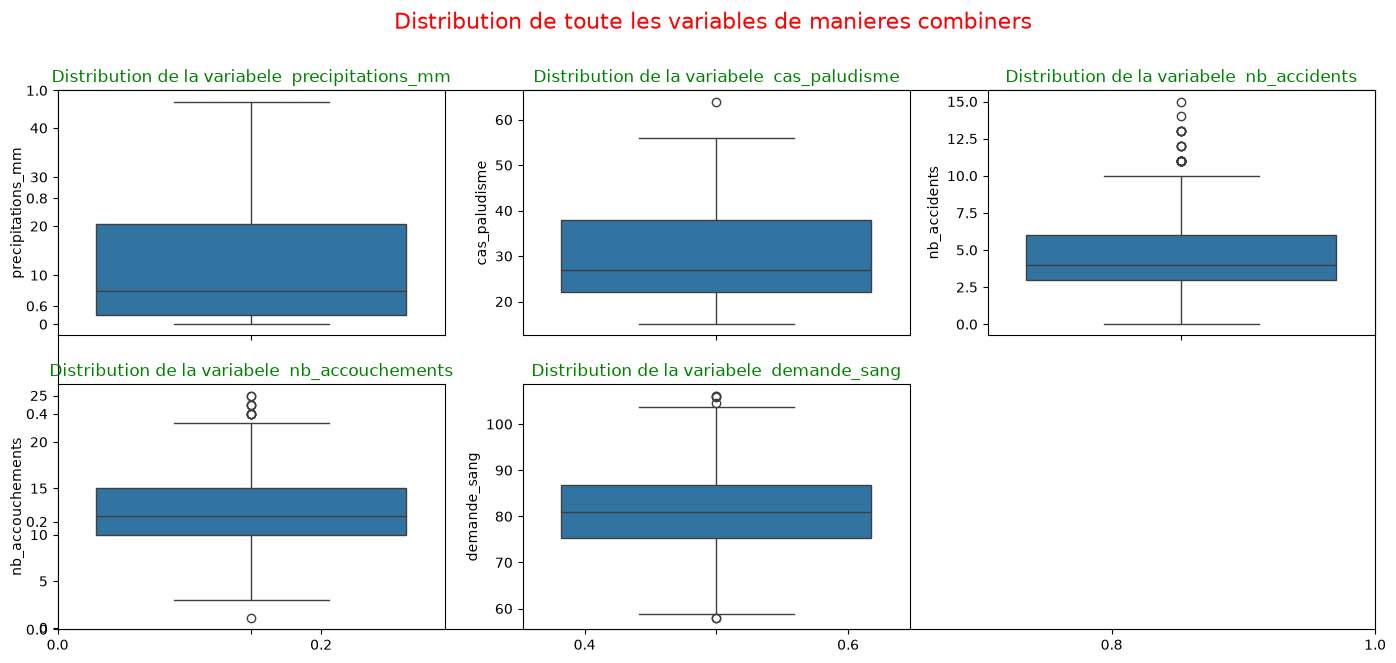

In [ ]:
plt.figure(figsize=(17,7))
plt.title("Distribution de toute les variables de manieres combiners \n\n", color = "red", size = 16)
for i in range(1,len(colonnes)):
    plt.subplot(2, 3, i)
    plt.title(f"Distribution de la variabele  {colonnes[i]}", color = "green")
    sns.boxplot(data= donnes,  y = donnes[colonnes[i]])


<Axes: >

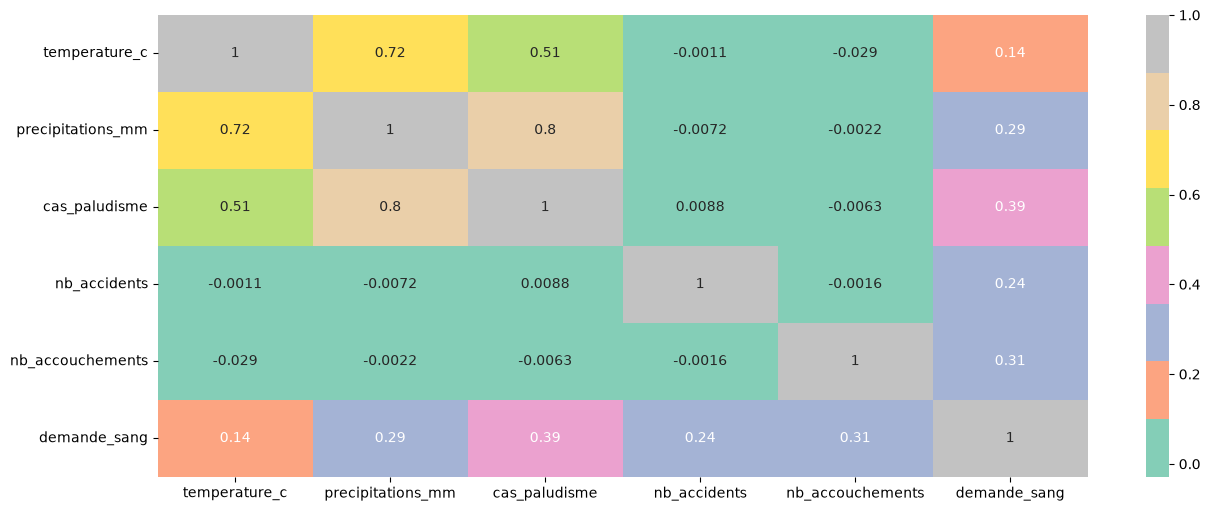

In [50]:
plt.figure(figsize= (15,6))
sns.heatmap(donnes.corr(numeric_only=True), annot= True, alpha = 0.8, cmap = "Set2")